# Data Processing – Seeds Dataset

Notebook này xử lý `seeds_dataset.csv` và tạo hai file:

- `seeds_train.csv`
- `seeds_test.csv`

Quy trình:

1. Đọc dữ liệu.
2. Chuẩn hóa tên cột.
3. Kiểm tra kiểu dữ liệu, missing values và duplicate.
4. Kiểm tra phân bố target.
5. Chia train/test theo tỷ lệ 80/20 với `stratify`.
6. Lưu hai file CSV.

> Chưa chuẩn hóa bằng `StandardScaler` ở notebook này. Scaling sẽ được thực hiện khi train mô hình để tránh data leakage.


In [2]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


## 1. Khai báo đường dẫn

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd '/content/drive/MyDrive/MLIotLab_HCMUT/mliot-pyml-2026-hw/week04/Homework_b7/'

/content/drive/MyDrive/MLIotLab_HCMUT/mliot-pyml-2026-hw/week04/Homework_b7


In [5]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("Dry_Bean_Dataset") / "Dry_Bean_Dataset.xlsx"

OUTPUT_DIR = DATA_PATH.parent
TRAIN_OUTPUT_PATH = OUTPUT_DIR / "dry_bean_train.csv"
TEST_OUTPUT_PATH = OUTPUT_DIR / "dry_bean_test.csv"

print("Đường dẫn:", DATA_PATH.resolve())
print("File tồn tại:", DATA_PATH.exists())

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy file tại: {DATA_PATH.resolve()}"
    )

Đường dẫn: /content/drive/MyDrive/MLIotLab_HCMUT/mliot-pyml-2026-hw/week04/Homework_b7/Dry_Bean_Dataset/Dry_Bean_Dataset.xlsx
File tồn tại: True


## 2. Đọc dữ liệu

In [6]:
%pip install openpyxl

In [7]:
df = pd.read_excel(
    DATA_PATH,
    engine="openpyxl"
)

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r"[^a-z0-9]+", "_", regex=True)
      .str.strip("_")
)

print(df.shape)
print(df["class"].head())
print(df["class"].unique())

(13611, 17)
0    SEKER
1    SEKER
2    SEKER
3    SEKER
4    SEKER
Name: class, dtype: object
['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']


## 3. Chuẩn hóa tên cột

In [8]:
target = "class"

numeric_columns = [
    column for column in df.columns
    if column != target
]

df[numeric_columns] = df[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

# Làm sạch target dạng chữ
df[target] = (
    df[target]
    .astype(str)
    .str.strip()
    .str.upper()
)

## 4. Kiểm tra cấu trúc dữ liệu

In [9]:
print("Thông tin dữ liệu:")
df.info()

print("\nThống kê mô tả:")
display(df.describe(include="all").T)


Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area             13611 non-null  int64  
 1   perimeter        13611 non-null  float64
 2   majoraxislength  13611 non-null  float64
 3   minoraxislength  13611 non-null  float64
 4   aspectration     13611 non-null  float64
 5   eccentricity     13611 non-null  float64
 6   convexarea       13611 non-null  int64  
 7   equivdiameter    13611 non-null  float64
 8   extent           13611 non-null  float64
 9   solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  compactness      13611 non-null  float64
 12  shapefactor1     13611 non-null  float64
 13  shapefactor2     13611 non-null  float64
 14  shapefactor3     13611 non-null  float64
 15  shapefactor4     13611 non-null  float64
 16  class            13611 non-null  object

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area,13611.0,NaN,NaN,NaN,53048.284549,29324.095717,20420.0,36328.0,44652.0,61332.0,254616.0
perimeter,13611.0,NaN,NaN,NaN,855.283459,214.289696,524.736,703.5235,794.941,977.213,1985.37
majoraxislength,13611.0,NaN,NaN,NaN,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
minoraxislength,13611.0,NaN,NaN,NaN,202.270714,44.970091,122.512653,175.84817,192.431733,217.031741,460.198497
aspectration,13611.0,NaN,NaN,NaN,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
eccentricity,13611.0,NaN,NaN,NaN,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
convexarea,13611.0,NaN,NaN,NaN,53768.200206,29774.915817,20684.0,36714.5,45178.0,62294.0,263261.0
equivdiameter,13611.0,NaN,NaN,NaN,253.06422,59.17712,161.243764,215.068003,238.438026,279.446467,569.374358
extent,13611.0,NaN,NaN,NaN,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
solidity,13611.0,NaN,NaN,NaN,0.987143,0.00466,0.919246,0.98567,0.988283,0.990013,0.994677


## 5. Kiểm tra missing values

In [10]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

display(missing)
print("Tổng số missing values:", df.isna().sum().sum())


,missing_count,missing_percent
area,0,0.0
perimeter,0,0.0
majoraxislength,0,0.0
minoraxislength,0,0.0
aspectration,0,0.0
eccentricity,0,0.0
convexarea,0,0.0
equivdiameter,0,0.0
extent,0,0.0
solidity,0,0.0


Tổng số missing values: 0


In [11]:
rows_before_missing = len(df)

df = df.dropna().reset_index(drop=True)

rows_after_missing = len(df)

print("Số hàng trước khi bỏ missing:", rows_before_missing)
print("Số hàng sau khi bỏ missing:", rows_after_missing)
print("Số hàng đã bỏ:", rows_before_missing - rows_after_missing)


Số hàng trước khi bỏ missing: 13611
Số hàng sau khi bỏ missing: 13611
Số hàng đã bỏ: 0


## 6. Kiểm tra và xóa duplicate

In [12]:
duplicate_count = df.duplicated().sum()

print("Số dòng trùng hoàn toàn:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)

print("Kích thước sau khi xóa duplicate:", df.shape)


Số dòng trùng hoàn toàn: 68
Kích thước sau khi xóa duplicate: (13543, 17)


## 7. Xác định feature và target

In [13]:
target = "class"

# Tất cả các cột ngoại trừ target đều là feature
features = [
    column for column in df.columns
    if column != target
]

X = df[features].copy()
y = df[target].copy()

print("Danh sách feature:")
print(features)

print("\nSố feature:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nPhân bố target:")
print(y.value_counts())

Danh sách feature:
['area', 'perimeter', 'majoraxislength', 'minoraxislength', 'aspectration', 'eccentricity', 'convexarea', 'equivdiameter', 'extent', 'solidity', 'roundness', 'compactness', 'shapefactor1', 'shapefactor2', 'shapefactor3', 'shapefactor4']

Số feature: 16
X shape: (13543, 16)
y shape: (13543,)

Phân bố target:
class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


## 9. Kiểm tra phân bố target

In [14]:
print("Số lượng từng lớp:")
print(y.value_counts().sort_index())

print("\nTỷ lệ từng lớp:")
print(y.value_counts(normalize=True).sort_index().round(4))

print("\nCác nhãn có trong target:")
print(sorted(y.unique()))


Số lượng từng lớp:
class
BARBUNYA    1322
BOMBAY       522
CALI        1630
DERMASON    3546
HOROZ       1860
SEKER       2027
SIRA        2636
Name: count, dtype: int64

Tỷ lệ từng lớp:
class
BARBUNYA    0.0976
BOMBAY      0.0385
CALI        0.1204
DERMASON    0.2618
HOROZ       0.1373
SEKER       0.1497
SIRA        0.1946
Name: proportion, dtype: float64

Các nhãn có trong target:
['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


## 10. Chia train/test

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (10834, 16)
Test shape: (2709, 16)


## 11. Ghép feature và target

In [16]:
train_df = X_train.copy()
train_df[target] = y_train

test_df = X_test.copy()
test_df[target] = y_test

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

display(train_df.head())


,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4,class
0,69471,1069.638,399.100245,225.005782,1.773733,0.825923,71088,297.410868,0.707386,0.977254,0.763027,0.745203,0.005745,0.001093,0.555328,0.985004,CALI
1,82877,1162.581,391.817013,270.836144,1.446694,0.722634,84171,324.841921,0.825986,0.984627,0.770544,0.829065,0.004728,0.001378,0.687349,0.994384,BARBUNYA
2,65042,1023.506,419.202858,198.962774,2.106941,0.880190,65748,287.774298,0.783403,0.989262,0.780231,0.686480,0.006445,0.000883,0.471255,0.992906,HOROZ
3,41315,758.920,287.438268,183.447580,1.566869,0.769858,41704,229.355383,0.791930,0.990672,0.901417,0.797929,0.006957,0.001740,0.636691,0.997611,SIRA
4,91088,1168.645,459.300729,253.950486,1.808623,0.833243,91799,340.553731,0.789051,0.992255,0.838119,0.741461,0.005042,0.000940,0.549765,0.994318,CALI


## 12. Kiểm tra phân bố lớp sau khi chia

In [17]:
print("Phân bố lớp trong train:")
print(train_df[target].value_counts().sort_index())

print("\nTỷ lệ lớp trong train:")
print(train_df[target].value_counts(normalize=True).sort_index().round(4))

print("\nPhân bố lớp trong test:")
print(test_df[target].value_counts().sort_index())

print("\nTỷ lệ lớp trong test:")
print(test_df[target].value_counts(normalize=True).sort_index().round(4))


Phân bố lớp trong train:
class
BARBUNYA    1057
BOMBAY       418
CALI        1304
DERMASON    2837
HOROZ       1488
SEKER       1621
SIRA        2109
Name: count, dtype: int64

Tỷ lệ lớp trong train:
class
BARBUNYA    0.0976
BOMBAY      0.0386
CALI        0.1204
DERMASON    0.2619
HOROZ       0.1373
SEKER       0.1496
SIRA        0.1947
Name: proportion, dtype: float64

Phân bố lớp trong test:
class
BARBUNYA    265
BOMBAY      104
CALI        326
DERMASON    709
HOROZ       372
SEKER       406
SIRA        527
Name: count, dtype: int64

Tỷ lệ lớp trong test:
class
BARBUNYA    0.0978
BOMBAY      0.0384
CALI        0.1203
DERMASON    0.2617
HOROZ       0.1373
SEKER       0.1499
SIRA        0.1945
Name: proportion, dtype: float64


## 13. Lưu thành hai file CSV

In [18]:
train_df.to_csv(TRAIN_OUTPUT_PATH, index=False)
test_df.to_csv(TEST_OUTPUT_PATH, index=False)

print("Đã lưu file train:", TRAIN_OUTPUT_PATH.resolve())
print("Đã lưu file test:", TEST_OUTPUT_PATH.resolve())


Đã lưu file train: /content/drive/MyDrive/MLIotLab_HCMUT/mliot-pyml-2026-hw/week04/Homework_b7/Dry_Bean_Dataset/dry_bean_train.csv
Đã lưu file test: /content/drive/MyDrive/MLIotLab_HCMUT/mliot-pyml-2026-hw/week04/Homework_b7/Dry_Bean_Dataset/dry_bean_test.csv


## 14. Kiểm tra lại file đã lưu

In [19]:
saved_train = pd.read_csv(TRAIN_OUTPUT_PATH)
saved_test = pd.read_csv(TEST_OUTPUT_PATH)

print("Saved train shape:", saved_train.shape)
print("Saved test shape:", saved_test.shape)

print("\nMissing trong train:", saved_train.isna().sum().sum())
print("Missing trong test:", saved_test.isna().sum().sum())

print("\nCác cột trong train:")
print(saved_train.columns.tolist())


Saved train shape: (10834, 17)
Saved test shape: (2709, 17)

Missing trong train: 0
Missing trong test: 0

Các cột trong train:
['area', 'perimeter', 'majoraxislength', 'minoraxislength', 'aspectration', 'eccentricity', 'convexarea', 'equivdiameter', 'extent', 'solidity', 'roundness', 'compactness', 'shapefactor1', 'shapefactor2', 'shapefactor3', 'shapefactor4', 'class']


## 15. Xây dựng mô hình Logistic Regression

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt



## Modeling Logistics Regression

In [21]:
preprocessor = StandardScaler()
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

log_reg_model = LogisticRegression(
    solver = 'liblinear',
    multi_class = 'ovr',
    random_state = 42,
    max_iter = 1000,
)
log_reg_model.fit(X_train_scaled, y_train)

print('Logistic Regression model has been trained.')


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression model has been trained.


Accuracy: 0.9150978220745662
Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.86      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.95      0.93       326
    DERMASON       0.93      0.89      0.91       709
       HOROZ       0.97      0.94      0.96       372
       SEKER       0.95      0.93      0.94       406
        SIRA       0.82      0.90      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



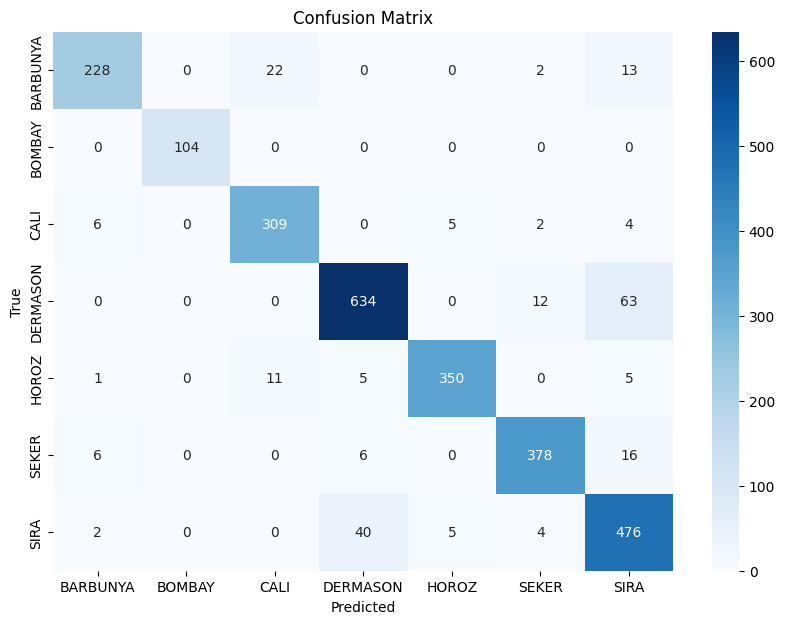

In [22]:
log_y_pred = log_reg_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, log_y_pred)
print(f'Accuracy: {log_accuracy}')

log_classification = classification_report(y_test, log_y_pred)
print(f'Classification Report:\n{log_classification}')

log_confusion = confusion_matrix(y_test, log_y_pred)

df_log_confusion = pd.DataFrame(log_confusion, index=log_reg_model.classes_, columns=log_reg_model.classes_)

plt.figure(figsize=(10, 7))
sns.heatmap(
    df_log_confusion,
    annot=True, fmt='d', cmap='Blues'
    )
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



## Modeling k-NN

In [24]:
print(f'Classification Logistic Regression', classification_report(y_test, log_y_pred))

Classification Logistic Regression               precision    recall  f1-score   support

    BARBUNYA       0.94      0.86      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.95      0.93       326
    DERMASON       0.93      0.89      0.91       709
       HOROZ       0.97      0.94      0.96       372
       SEKER       0.95      0.93      0.94       406
        SIRA       0.82      0.90      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



## 16. Đánh giá mô hình

SIRA class has lowest precision in two models.

The accuracy of two models is high and not sinificantly larger than the other.

BOMBAY class is easily to define. Prove it is so specified to classify.

